<a href="https://colab.research.google.com/github/Sreeja0308/skaithi_64061/blob/main/Assignment_4_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
from operator import itemgetter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
get_ipython().magic(u'matplotlib inline')
plt.style.use('ggplot')

import tensorflow as tf

from keras import models, regularizers, layers, optimizers, losses, metrics
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical

Positive and negative sentiment labels are attached to movie reviews in the IMDB dataset.

The preprocessing of the dataset involves turning every review into a series of word embeddings, where every word is represented by a fixed-size vector.

In [ ]:
from keras.layers import Embedding

# The Embedding layer requires a minimum of two inputs:
# The maximum word index plus one, or 1000, is the number of potential tokens.
# and the embeddings' dimensions, in this case 64.
embedd_lay = Embedding(1000, 64)
from keras.datasets import imdb
from keras import preprocessing
from keras.utils import pad_sequences

custom-trained embedding layer with training sample size of 100

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - acc: 0.5125 - loss: 0.6938 - val_acc: 0.6500 - val_loss: 0.6921
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - acc: 0.8875 - loss: 0.6688 - val_acc: 0.6000 - val_loss: 0.6922
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - acc: 0.9625 - loss: 0.6509 - val_acc: 0.6000 - val_loss: 0.6919
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - acc: 0.9875 - loss: 0.6343 - val_acc: 0.5500 - val_loss: 0.6922
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - acc: 0.9875 - loss: 0.6182 - val_acc: 0.5500 - val_loss: 0.6925
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - acc: 0.9875 - loss: 0.6020 - val_acc: 0.4500 - val_loss: 0.6935
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - acc: 0.9875 - loss: 0.5854 - val_acc: 0.4500 - val_loss: 0.6937
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - acc: 0.9875 - loss: 0.5687 - val_acc: 0.4500 - val_loss: 0.6935
Epoch 9/10
3/3 ━━━━━━━━━━━━━

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 8)         │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,404 (634.39 KB)

 Trainable params: 81,201 (317.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,203 (317.20 KB)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.4938 - loss: 0.6950
Test Loss: 0.6949796676635742
Test Accuracy: 0.49380001425743103


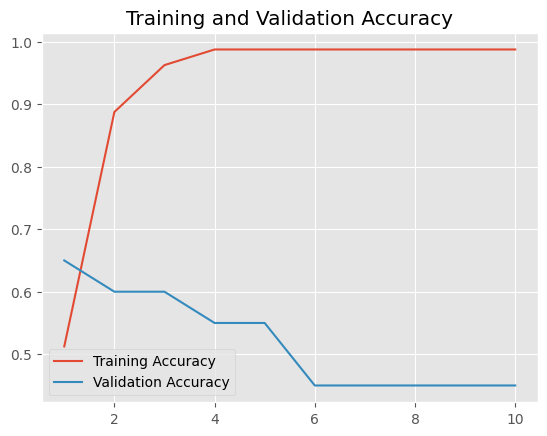

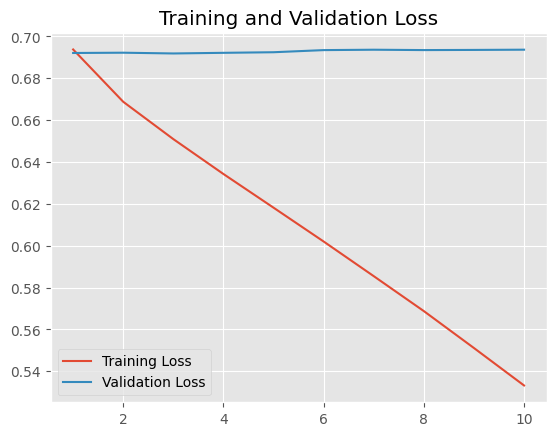

In [ ]:
import numpy as np
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense
import matplotlib.pyplot as plt

# Parameters
features = 10000  # Top 10,000 most frequent words
length = 150      # Pad sequences to length 150

# Load and preprocess the data
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=features)
x_train = x_train[:100]
y_train = y_train[:100]
x_train = pad_sequences(x_train, maxlen=length)
x_test = pad_sequences(x_test, maxlen=length)

# Build the model
model1 = Sequential()
model1.add(Embedding(input_dim=features, output_dim=8, input_length=length))
model1.add(Flatten())
model1.add(Dense(1, activation='sigmoid'))

# Compile the model
model1.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

# Train the model
history1 = model1.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# Print final model summary
model1.summary()

# Evaluate on test data
test_loss, test_acc = model1.evaluate(x_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

# Plot training history
acc = history1.history['acc']
val_acc = history1.history['val_acc']
loss = history1.history['loss']
val_loss = history1.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()


In [ ]:
test_loss, test_acc = model1.evaluate(x_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.4938 - loss: 0.6950
Test loss: 0.6949796676635742
Test accuracy: 0.49380001425743103


custom-trained embedding layer with training sample size of 5000

In [ ]:
import numpy as np
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences

# Parameters
features = 10000
length = 150

# Load data
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=features)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=length)
x_test = pad_sequences(x_test, maxlen=length)

# Combine text and label arrays
texts = np.concatenate((x_train, x_test), axis=0)
labels = np.concatenate((y_train, y_test), axis=0)

# Trim training set to 5000 samples
x_train = x_train[:5000]
y_train = y_train[:5000]


In [ ]:
# Define and compile the model
model2 = Sequential()
model2.add(Embedding(10000, 8, input_length=150))
model2.add(Flatten())
model2.add(Dense(1, activation='sigmoid'))
model2.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

# Fit the model FIRST (this builds it)
history2 = model2.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


model2.summary()

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.5288 - loss: 0.6915 - val_acc: 0.5670 - val_loss: 0.6885
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.7470 - loss: 0.6612 - val_acc: 0.6900 - val_loss: 0.6615
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.8315 - loss: 0.5844 - val_acc: 0.7380 - val_loss: 0.5935
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.8763 - loss: 0.4693 - val_acc: 0.7820 - val_loss: 0.5168
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9018 - loss: 0.3633 - val_acc: 0.7980 - val_loss: 0.4610
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9235 - loss: 0.2842 - val_acc: 0.8100 - val_loss: 0.4321
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9427 - loss: 0.2259 - val_acc: 0.8170 - val_loss: 0.4122
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.9603 - loss: 0.1805 - val_acc: 0.8200 - val_loss: 0.4023
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - ac

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (32, 150, 8)           │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 1200)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 1)                │         1,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,404 (634.39 KB)

 Trainable params: 81,201 (317.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,203 (317.20 KB)

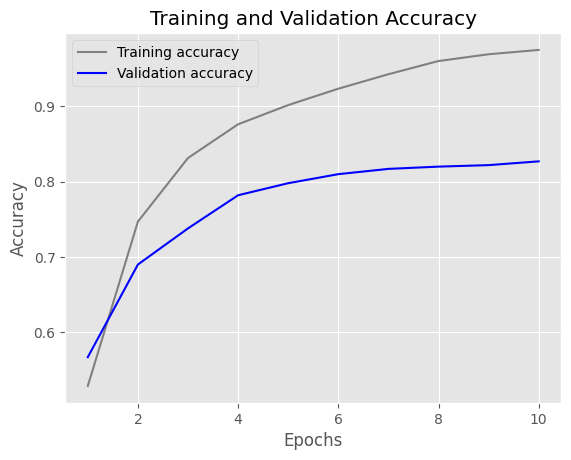

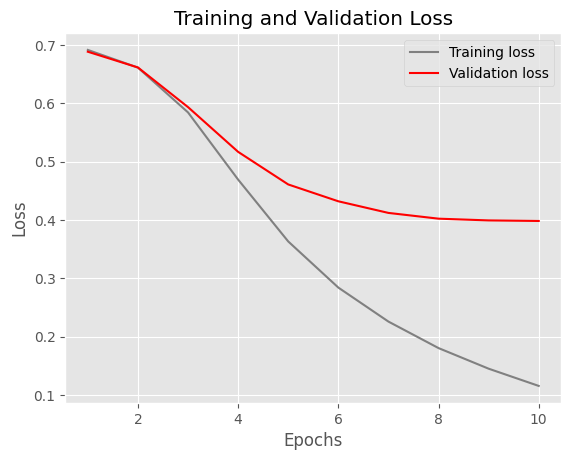

In [ ]:
import matplotlib.pyplot as plt

# Extract metrics
accuracy2 = history2.history['acc']
validation_accuracy2 = history2.history['val_acc']
Train_loss2 = history2.history['loss']
validation_loss2 = history2.history['val_loss']

# Epoch range
epochs = range(1, len(accuracy2) + 1)

# Plot Accuracy
plt.figure()
plt.plot(epochs, accuracy2, 'grey', label='Training accuracy')
plt.plot(epochs, validation_accuracy2, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.figure()
plt.plot(epochs, Train_loss2, 'grey', label='Training loss')
plt.plot(epochs, validation_loss2, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Evaluating the model on test data
test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test)

# Printing results
print('Test loss:', test_loss2)
print('Test accuracy:', test_accuracy2)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.8312 - loss: 0.3726
Test loss: 0.3726426959037781
Test accuracy: 0.8312000036239624


In [ ]:
import numpy as np
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences

# Parameters
features = 10000
length = 150

# Load the dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=features)

# Pad all sequences
x_train = pad_sequences(x_train, maxlen=length)
x_test = pad_sequences(x_test, maxlen=length)

# Combine text and label arrays
texts = np.concatenate((x_train, x_test), axis=0)
labels = np.concatenate((y_train, y_test), axis=0)

# Limit training data to first 1000 samples
x_train = x_train[:1000]
y_train = y_train[:1000]

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense

features = 10000
length = 150

# Build the model and name it exactly like you want
model2 = Sequential(name="sequential_2")
model2.add(Embedding(input_dim=features, output_dim=8, input_length=length, name="embedding_3"))
model2.add(Flatten(name="flatten_2"))
model2.add(Dense(1, activation='sigmoid', name="dense_2"))

# Compile the model
model2.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

# Manually build the model to initialize layer shapes
model2.build(input_shape=(None, length))

# Now print the summary – this will give you your desired output
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 150, 8)         │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,201 (317.19 KB)

 Trainable params: 81,201 (317.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model for 10 epochs
history2 = model2.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 1.0000 - loss: 0.0635 - val_acc: 0.6050 - val_loss: 0.6588
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 1.0000 - loss: 0.0522 - val_acc: 0.6250 - val_loss: 0.6609
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 1.0000 - loss: 0.0430 - val_acc: 0.6250 - val_loss: 0.6647
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 1.0000 - loss: 0.0352 - val_acc: 0.6300 - val_loss: 0.6687
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 1.0000 - loss: 0.0291 - val_acc: 0.6300 - val_loss: 0.6738
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 1.0000 - loss: 0.0239 - val_acc: 0.6300 - val_loss: 0.6790
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 1.0000 - loss: 0.0197 - val_acc: 0.6400 - val_loss: 0.6842
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 1.0000 - loss: 0.0164 - val_acc: 0.6500 - val_loss: 0.6907
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 1.0000 - loss:

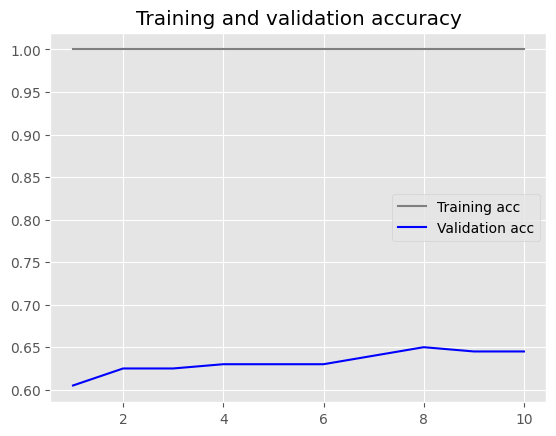

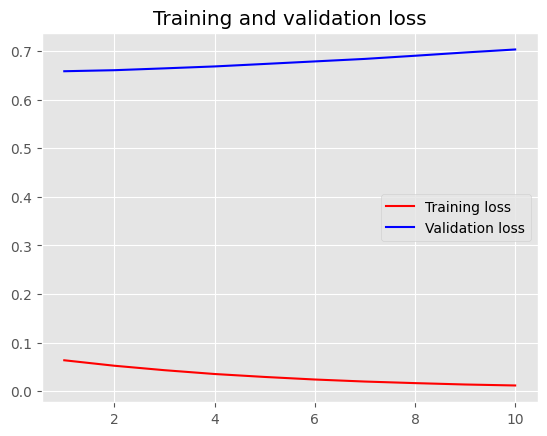

In [ ]:
accuracy3 = history2.history["acc"]
validation_accuracy3 = history2.history["val_acc"]
Train_loss3 = history2.history["loss"]
validation_loss3 = history2.history["val_loss"]

epochs = range(1, len(accuracy3) + 1)

plt.plot(epochs, accuracy3, "grey", label = "Training acc")
plt.plot(epochs, validation_accuracy3, "b", label = "Validation acc")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, Train_loss3, "red", label = "Training loss")
plt.plot(epochs, validation_loss3, "b", label = "Validation loss")
plt.title("Training and validation loss")
plt.legend()

plt.show()

In [ ]:
# Evaluate model2 on the test data
test_loss3, test_accuracy3 = model2.evaluate(x_test, y_test)

# Print the test loss and accuracy
print('Test loss:', test_loss3)
print('Test accuracy:', test_accuracy3)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.6082 - loss: 0.7391
Test loss: 0.7390881776809692
Test accuracy: 0.608240008354187


In [ ]:
import numpy as np
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences

# Parameters
features = 10000
length = 150

# Load the dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=features)

# Pad all sequences
x_train = pad_sequences(x_train, maxlen=length)
x_test = pad_sequences(x_test, maxlen=length)

# Combine text and label arrays
texts = np.concatenate((x_train, x_test), axis=0)
labels = np.concatenate((y_train, y_test), axis=0)

# Limit training data to first 1000 samples
x_train = x_train[:1000]
y_train = y_train[:1000]


In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense

features = 10000
length = 150

# Build the model and name it exactly like you want
model2 = Sequential(name="sequential_2")
model2.add(Embedding(input_dim=features, output_dim=8, input_length=length, name="embedding_3"))
model2.add(Flatten(name="flatten_2"))
model2.add(Dense(1, activation='sigmoid', name="dense_2"))

# Compile the model
model2.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

# Manually build the model to initialize layer shapes
model2.build(input_shape=(None, length))

# Now print the summary – this will give you your desired output
model2.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 150, 8)         │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,201 (317.19 KB)

 Trainable params: 81,201 (317.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model for 10 epochs
history2 = model2.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - acc: 0.4988 - loss: 0.6930 - val_acc: 0.5500 - val_loss: 0.6908
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.7912 - loss: 0.6752 - val_acc: 0.5700 - val_loss: 0.6897
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9025 - loss: 0.6572 - val_acc: 0.5600 - val_loss: 0.6881
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9337 - loss: 0.6344 - val_acc: 0.5900 - val_loss: 0.6859
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9425 - loss: 0.6062 - val_acc: 0.5550 - val_loss: 0.6833
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9463 - loss: 0.5725 - val_acc: 0.5500 - val_loss: 0.6805
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9563 - loss: 0.5341 - val_acc: 0.5500 - val_loss: 0.6776
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9675 - loss: 0.4919 - val_acc: 0.5600 - val_loss: 0.6746
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9787 - loss:

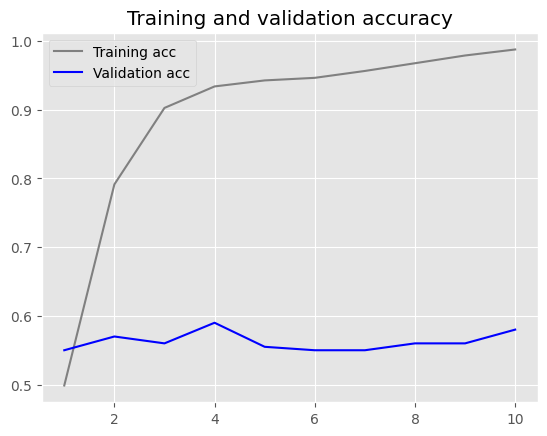

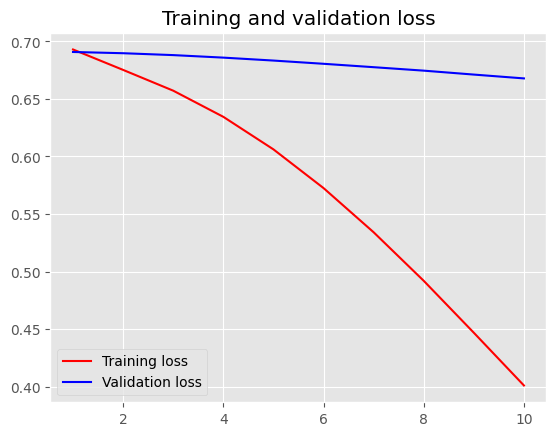

In [ ]:
accuracy3 = history2.history["acc"]
validation_accuracy3 = history2.history["val_acc"]
Train_loss3 = history2.history["loss"]
validation_loss3 = history2.history["val_loss"]

epochs = range(1, len(accuracy3) + 1)

plt.plot(epochs, accuracy3, "grey", label = "Training acc")
plt.plot(epochs, validation_accuracy3, "b", label = "Validation acc")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, Train_loss3, "red", label = "Training loss")
plt.plot(epochs, validation_loss3, "b", label = "Validation loss")
plt.title("Training and validation loss")
plt.legend()

plt.show()


In [ ]:
# Evaluate model2 on the test data
test_loss3, test_accuracy3 = model2.evaluate(x_test, y_test)

# Print the test loss and accuracy
print('Test loss:', test_loss3)
print('Test accuracy:', test_accuracy3)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.5532 - loss: 0.6839
Test loss: 0.6839359402656555
Test accuracy: 0.5532400012016296


In [ ]:
# Parameters
features = 10000
length = 150

# Load the IMDB dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=features)

# Pad sequences
x_train = pad_sequences(x_train, maxlen=length)
x_test = pad_sequences(x_test, maxlen=length)

# Combine text and label arrays
texts = np.concatenate((x_train, x_test), axis=0)
labels = np.concatenate((y_train, y_test), axis=0)

# Reduce training set to first 10,000 samples
x_train = x_train[:10000]
y_train = y_train[:10000]

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
import numpy as np

# Parameters
features = 10000
length = 150

# Load and preprocess data
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=features)
x_train = pad_sequences(x_train, maxlen=length)
x_test = pad_sequences(x_test, maxlen=length)
x_train = x_train[:10000]
y_train = y_train[:10000]

# Build model
model4 = Sequential(name="sequential_4")
model4.add(Embedding(10000, 8, input_length=length, name="embedding_4"))
model4.add(Flatten(name="flatten_4"))
model4.add(Dense(1, activation='sigmoid', name="dense_4"))
model4.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

# Train model (this builds the model)
history4 = model4.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# Now call summary AFTER fitting (model is built now)
model4.summary()

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.5835 - loss: 0.6831 - val_acc: 0.6880 - val_loss: 0.6517
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.7879 - loss: 0.5545 - val_acc: 0.8170 - val_loss: 0.4751
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8516 - loss: 0.3900 - val_acc: 0.8500 - val_loss: 0.3748
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.8869 - loss: 0.2982 - val_acc: 0.8580 - val_loss: 0.3365
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.9153 - loss: 0.2425 - val_acc: 0.8580 - val_loss: 0.3302
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9325 - loss: 0.2027 - val_acc: 0.8580 - val_loss: 0.3172
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9444 - loss: 0.1683 - val_acc: 0.8565 - val_loss: 0.3218
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9575 - loss: 0.1408 - val_acc: 0.8550 - val_loss: 0.3237
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - ac

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (32, 150, 8)           │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (32, 1200)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 1)                │         1,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,404 (634.39 KB)

 Trainable params: 81,201 (317.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,203 (317.20 KB)

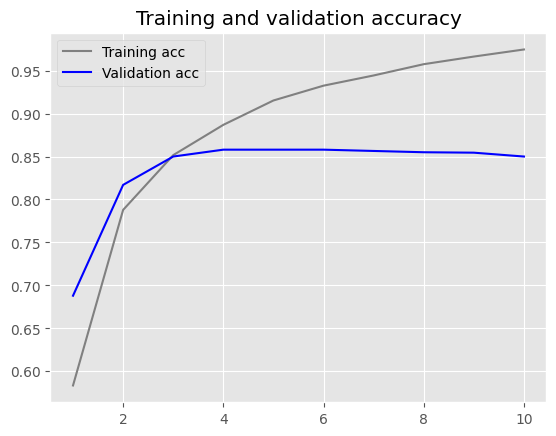

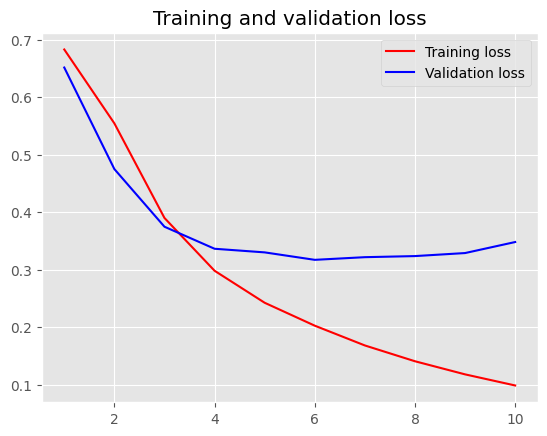

In [ ]:
accuracy4 = history4.history["acc"]
validation_accuracy4 = history4.history["val_acc"]
Train_loss4 = history4.history["loss"]
validation_loss4 = history4.history["val_loss"]

epochs = range(1, len(accuracy4) + 1)

plt.plot(epochs, accuracy4, "grey", label = "Training acc")
plt.plot(epochs, validation_accuracy4, "b", label = "Validation acc")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, Train_loss4, "red", label = "Training loss")
plt.plot(epochs, validation_loss4, "b", label = "Validation loss")
plt.title("Training and validation loss")
plt.legend()

plt.show()

In [ ]:
# Evaluate model4 on the test dataset
test_loss4, test_accuracy4 = model4.evaluate(x_test, y_test)

# Display results
print('Test loss:', test_loss4)
print('Test accuracy:', test_accuracy4)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.8500 - loss: 0.3530
Test loss: 0.3530258238315582
Test accuracy: 0.8499600291252136


In [ ]:
!curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xf aclImdb_v1.tar.gz
!rm -r aclImdb/train/unsup

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80.2M  100 80.2M    0     0  10.3M      0  0:00:07  0:00:07 --:--:-- 16.8M


In [ ]:
import os

# Path to the IMDB dataset directory
imdb_dir = 'aclImdb'
train_dir = os.path.join(imdb_dir, 'train')

# Initialize lists to hold text data and labels
texts = []   # List of review strings
labels = []  # List of 0 (negative) or 1 (positive)

# Loop through each category folder
for label_type in ['neg', 'pos']:
    dir_path = os.path.join(train_dir, label_type)

    for fname in os.listdir(dir_path):
        if fname.endswith('.txt'):  # Only read text files
            with open(os.path.join(dir_path, fname), encoding='utf-8') as f:
                texts.append(f.read())

            # Assign label: 0 for 'neg', 1 for 'pos'
            labels.append(0 if label_type == 'neg' else 1)

If you don’t have enough training data to learn word embeddings from scratch, you can use pretrained word embeddings to help you solve your problem.

Breaking the data into tokens

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

length2 = 150        # Cut off review after 150 words
train_data = 100     # Training samples
valid_data = 10000   # Validation samples
words = 10000        # Use top 10,000 words only

# Tokenization
tokenizer1 = Tokenizer(num_words=words)
tokenizer1.fit_on_texts(texts)
sequences = tokenizer1.texts_to_sequences(texts)

word_index = tokenizer1.word_index
print("Found %s unique tokens." % len(word_index))

# Padding
data = pad_sequences(sequences, maxlen=length2)

# Convert labels to numpy array
labels = np.asarray(labels)
print("Shape of data tensor:", data.shape)
print("Shape of label tensor:", labels.shape)

# Shuffle and split
indices = np.arange(data.shape[0])
np.random.shuffle(indices)
data = data[indices]
labels = labels[indices]

x_train = data[:train_data]
y_train = labels[:train_data]
x_validation = data[train_data:train_data + valid_data]
y_validation = labels[train_data:train_data + valid_data]

Found 88582 unique tokens.
Shape of data tensor: (25000, 150)
Shape of label tensor: (25000,)


Set up the GloVe word embeddings.

In [ ]:
import numpy as np
import requests
from io import BytesIO
import zipfile

# URL to download GloVe embeddings (6B tokens, 100D vectors)
glove_url = 'https://nlp.stanford.edu/data/glove.6B.zip'

# Download the zip file from Stanford NLP
glove_zip = requests.get(glove_url)

# Extract the zip file to /content/glove
with zipfile.ZipFile(BytesIO(glove_zip.content)) as z:
    z.extractall('/content/glove')

# Load the GloVe embeddings into a dictionary
embeddings_index = {}
glove_file_path = '/content/glove/glove.6B.100d.txt'

with open(glove_file_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

# Display number of words in the GloVe embedding index
print("Found %s word vectors." % len(embeddings_index))

Found 400000 word vectors.


We trained the GloVe 6B model using Wikipedia and Gigaword 5, giving it 6 billion tokens across about 400,000 words. Get the GloVe embeddings matrix by loading a pre-trained word layer trained on 100 samples.

In [ ]:
# Set embedding dimension (should match the GloVe file you loaded)
embedd_di = 100

# Initialize embedding matrix with zeros: shape = (max words, embedding dim)
embedding_matrix = np.zeros((words, embedd_di))

# Fill embedding matrix with GloVe vectors where available
for word, i in word_index.items():
    if i < words:
        embedd_vector = embeddings_index.get(word)
        if embedd_vector is not None:
            embedding_matrix[i] = embedd_vector

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense

model = Sequential(name="sequential_8")
model.add(Embedding(words, embedd_di, input_length=length2, name="embedding_9"))
model.add(Flatten(name="flatten_8"))
model.add(Dense(32, activation='relu', name="dense_9"))
model.add(Dense(1, activation='sigmoid', name="dense_10"))

# Fix: build model before calling summary
model.build(input_shape=(None, length2))
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 150, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 15000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │       480,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,480,065 (5.65 MB)

 Trainable params: 1,480,065 (5.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.layers[0].set_weights([embedding_matrix])
model.layers[0].trainable = False

The embedding layer uses pre-trained word vectors. When you set it to False for the Embedding layer, it will not be trainable. Turn trainable to True, and the optimizer can adjust the word embedding settings. If you want students to keep what they already know, don’t change the pretrained parts while they’re still learning.

In [ ]:
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_validation, y_validation))

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 421ms/step - acc: 0.5900 - loss: 2.2831 - val_acc: 0.5246 - val_loss: 0.6916
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 335ms/step - acc: 0.6700 - loss: 0.5520 - val_acc: 0.5241 - val_loss: 0.6917
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 529ms/step - acc: 0.7100 - loss: 0.5874 - val_acc: 0.5009 - val_loss: 0.7187
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 586ms/step - acc: 0.7900 - loss: 0.3684 - val_acc: 0.5005 - val_loss: 0.8702
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 342ms/step - acc: 0.8200 - loss: 0.3126 - val_acc: 0.5005 - val_loss: 1.1184
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 347ms/step - acc: 0.8500 - loss: 0.3075 - val_acc: 0.5006 - val_loss: 1.0703
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 341ms/step - acc: 0.9700 - loss: 0.1801 - val_acc: 0.5004 - val_loss: 1.5339
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 342ms/step - acc: 0.9500 - loss: 0.1792 - val_acc: 0.5599 - val_loss: 0.7052
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 358ms/step - acc: 1.0000 - loss: 

In [ ]:
model.save_weights('pre_trained_glove_model.weights.h5')

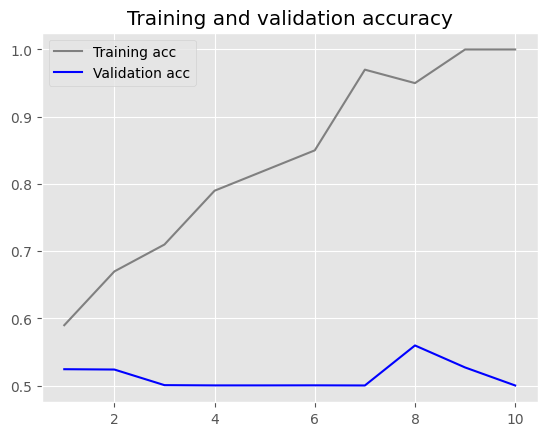

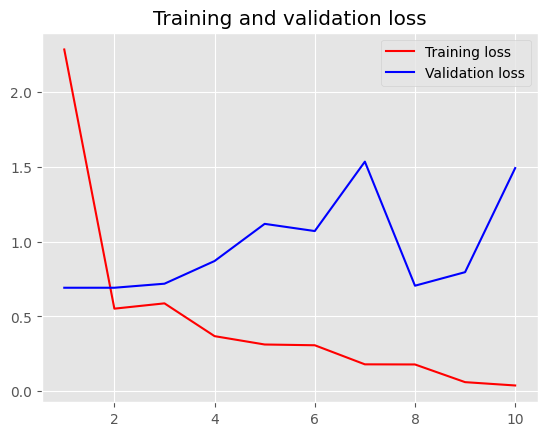

In [ ]:
 import matplotlib.pyplot as plt

accuracy = history.history['acc']
valid_accuracy = history.history['val_acc']
train_loss = history.history['loss']
valid_loss = history.history['val_loss']

epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, 'grey', label='Training acc')
plt.plot(epochs, valid_accuracy, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, train_loss, 'red', label='Training loss')
plt.plot(epochs, valid_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [ ]:
test_loss, test_accuracy= model.evaluate(x_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.5000 - loss: 1.6432
Test loss: 1.6431907415390015
Test accuracy: 0.4999600052833557


A pretrained word-embedding layer trained on 5,000 samples.

Found 88582 unique tokens.
Shape of data tensor: (25000, 150)
Shape of label tensor: (25000,)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 150, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 15000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │       480,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,480,065 (5.65 MB)

 Trainable params: 1,480,065 (5.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - acc: 0.4902 - loss: 0.7504 - val_acc: 0.4995 - val_loss: 0.6931
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - acc: 0.5014 - loss: 0.6964 - val_acc: 0.5006 - val_loss: 0.6931
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - acc: 0.5056 - loss: 0.6909 - val_acc: 0.4979 - val_loss: 0.7773
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - acc: 0.5342 - loss: 0.6873 - val_acc: 0.4994 - val_loss: 0.6986
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - acc: 0.5866 - loss: 0.6500 - val_acc: 0.4990 - val_loss: 0.7133
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - acc: 0.6612 - loss: 0.5968 - val_acc: 0.5026 - val_loss: 0.8061
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - acc: 0.7336 - loss: 0.5145 - val_acc: 0.5009 - val_loss: 1.0483
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - acc: 0.8070 - loss: 0.4281 - val_acc: 0.4988 - val_loss: 0.8640
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/

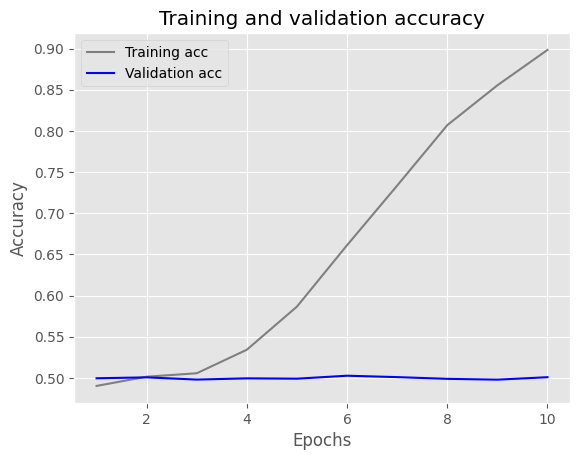

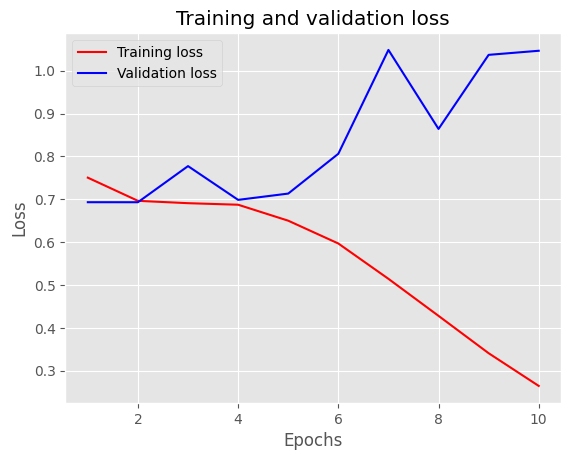

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
import numpy as np
import matplotlib.pyplot as plt

# Parameters
length2 = 150
train_data = 5000
valid_data = 10000
words = 10000
embedd_di = 100

# Tokenize and pad
tokenizer2 = Tokenizer(num_words=words)
tokenizer2.fit_on_texts(texts)
sequences = tokenizer2.texts_to_sequences(texts)
word_index = tokenizer2.word_index
print("Found %s unique tokens." % len(word_index))

data = pad_sequences(sequences, maxlen=length2)
labels = np.asarray(labels)
print("Shape of data tensor:", data.shape)
print("Shape of label tensor:", labels.shape)

# Shuffle and split
indices = np.arange(data.shape[0])
np.random.shuffle(indices)
data = data[indices]
labels = labels[indices]

x_train = data[:train_data]
y_train = labels[:train_data]
x_validation = data[train_data:train_data + valid_data]
y_validation = labels[train_data:train_data + valid_data]

# Prepare embedding matrix
embedd_matrix = np.zeros((words, embedd_di))
for word, i in word_index.items():
    if i < words:
        embedd_vector = embeddings_index.get(word)
        if embedd_vector is not None:
            embedd_matrix[i] = embedd_vector

from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense

# Parameters
words = 10000       # Vocabulary size
embedd_di = 100     # Embedding dimensions
length2 = 150       # Input sequence length

# Build the model
model11 = Sequential()
model11.add(Embedding(input_dim=words, output_dim=embedd_di, input_length=length2))
model11.add(Flatten())
model11.add(Dense(32, activation='relu'))
model11.add(Dense(1, activation='sigmoid'))

# Manually build the model to initialize shapes
model11.build(input_shape=(None, length2))

# Print the full summary with actual parameter counts
model11.summary()

# Build the model so we can set weights
model11.build(input_shape=(None, length2))

# Set pre-trained GloVe weights
model11.layers[0].set_weights([embedd_matrix])
model11.layers[0].trainable = False

# Compile and train
model11.compile(optimizer='rmsprop',
                loss='binary_crossentropy',
                metrics=['acc'])

history11 = model11.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_validation, y_validation)
)

# Save the weights
model11.save_weights('pre_trained_glove_model.weights.h5')

# Plot training and validation metrics
accuracy11 = history11.history['acc']
valid_acc11 = history11.history['val_acc']
train_loss11 = history11.history['loss']
valid_loss11 = history11.history['val_loss']

epochs = range(1, len(accuracy11) + 1)

plt.plot(epochs, accuracy11, 'grey', label='Training acc')
plt.plot(epochs, valid_acc11, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, train_loss11, 'red', label='Training loss')
plt.plot(epochs, valid_loss11, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
test_loss11, test_accuracy11 = model11.evaluate(x_test, y_test)
print('Test loss:', test_loss11)
print('Test accuracy:', test_accuracy11)


782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.4911 - loss: 1.0598
Test loss: 1.0597810745239258
Test accuracy: 0.49112001061439514


A pretrained word-embedding layer trained on 1,000 samples.

In [ ]:
import numpy as np

length = 150
train_data = 1000 #Trains on 1000 samples
valid_data = 10000
words = 10000

tokenizer3 = Tokenizer(num_words=words)
tokenizer3.fit_on_texts(texts)
sequences = tokenizer3.texts_to_sequences(texts)
word_index = tokenizer3.word_index
print("Found %s unique tokens." % len(word_index))

data = pad_sequences(sequences, maxlen=length)

labels = np.asarray(labels)
print("Shape of data tensor:", data.shape)
print("Shape of label tensor:", labels.shape)

indices = np.arange(data.shape[0])
np.random.shuffle(indices)
data = data[indices]
labels = labels[indices]

x_train = data[:train_data]
y_train = labels[:train_data]
x_val = data[train_data:train_data+valid_data]
y_val = labels[train_data:train_data+valid_data]
embedding_dim = 100

embedd_matrix = np.zeros((words, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if i < words:
        if embedding_vector is not None:

            embedd_matrix[i] = embedding_vector

Found 88582 unique tokens.
Shape of data tensor: (25000, 150)
Shape of label tensor: (25000,)


In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense

# Define model parameters
words = 10000
embedding_dim = 100
length = 150

# Build the model
model12 = Sequential()
model12.add(Embedding(words, embedding_dim, input_length=length))
model12.add(Flatten())
model12.add(Dense(32, activation='relu'))
model12.add(Dense(1, activation='sigmoid'))

# Build the model before setting weights
model12.build(input_shape=(None, length))

# Set pre-trained GloVe weights
model12.layers[0].set_weights([embedding_matrix])
model12.layers[0].trainable = False

# Compile the model
model12.compile(optimizer='rmsprop',
                loss='binary_crossentropy',
                metrics=['acc'])

# Train the model
history12 = model12.fit(x_train, y_train,
                        epochs=10,
                        batch_size=32,
                        validation_data=(x_val, y_val))

# Show summary after model is built
model12.summary()


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.4930 - loss: 1.0947 - val_acc: 0.5014 - val_loss: 0.6938
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - acc: 0.5430 - loss: 0.7074 - val_acc: 0.4968 - val_loss: 0.7515
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.6440 - loss: 0.6511 - val_acc: 0.4966 - val_loss: 0.9951
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - acc: 0.7350 - loss: 0.5202 - val_acc: 0.5000 - val_loss: 0.7884
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - acc: 0.8200 - loss: 0.4063 - val_acc: 0.5029 - val_loss: 0.8948
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 0.8530 - loss: 0.3622 - val_acc: 0.5070 - val_loss: 0.7792
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - acc: 0.9320 - loss: 0.2394 - val_acc: 0.5049 - val_loss: 1.0421
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.9390 - loss: 0.1868 - val_acc: 0.5008 - val_loss: 0.9965
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - acc: 0.9600

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 150, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 15000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │       480,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,960,132 (7.48 MB)

 Trainable params: 480,065 (1.83 MB)

 Non-trainable params: 1,000,000 (3.81 MB)

 Optimizer params: 480,067 (1.83 MB)

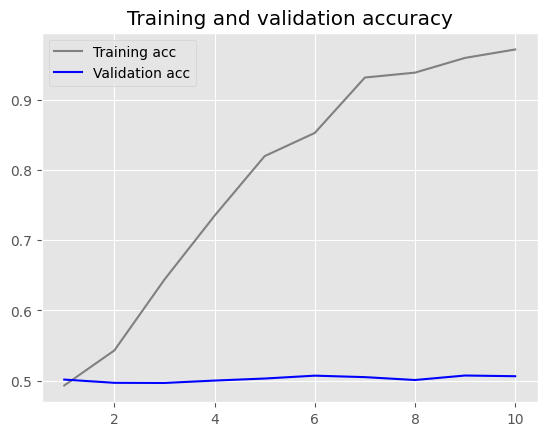

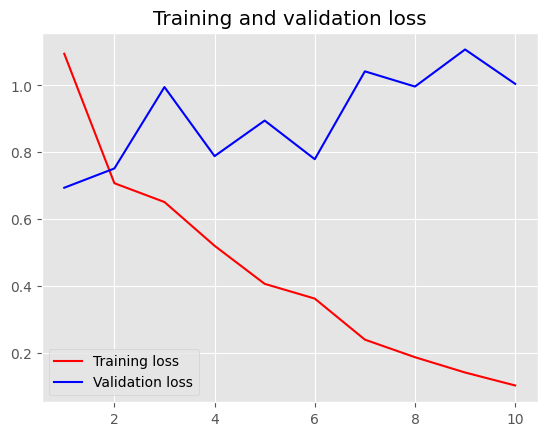

In [ ]:
import matplotlib.pyplot as plt

acc12 = history12.history['acc']
val_acc12 = history12.history['val_acc']
loss12 = history12.history['loss']
val_loss12 = history12.history['val_loss']

epochs = range(1, len(acc12) + 1)

plt.plot(epochs, acc12, 'grey', label='Training acc')
plt.plot(epochs, val_acc12, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss12, 'red', label='Training loss')
plt.plot(epochs, val_loss12, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [ ]:
test_loss12, test_accuracy12 = model12.evaluate(x_test, y_test)
print('Test loss:', test_loss12)
print('Test accuracy:', test_accuracy12)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.5065 - loss: 0.9935
Test loss: 0.9934552907943726
Test accuracy: 0.5065199732780457


A pretrained word-embedding layer trained on 10,000 samples.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# Parameters
length = 150
train_ds = 10000
valid_ds = 10000
words = 10000
embedd_dim = 100

# Tokenize the text
tokenizer4 = Tokenizer(num_words=words)
tokenizer4.fit_on_texts(texts)
sequences = tokenizer4.texts_to_sequences(texts)
word_index = tokenizer4.word_index
print("Found %s unique tokens." % len(word_index))

# Pad sequences
data = pad_sequences(sequences, maxlen=length)

# Convert labels to numpy array
labels = np.asarray(labels)
print("Shape of data tensor:", data.shape)
print("Shape of label tensor:", labels.shape)

# Shuffle the data
indices = np.arange(data.shape[0])
np.random.shuffle(indices)
data = data[indices]
labels = labels[indices]

# Split into training and validation sets
x_train = data[:train_ds]
y_train = labels[:train_ds]
x_val = data[train_ds:train_ds + valid_ds]
y_val = labels[train_ds:train_ds + valid_ds]

# Build the GloVe embedding matrix
embedd_matrix = np.zeros((words, embedd_dim))
for word, i in word_index.items():
    if i < words:
        embedd_vector = embeddings_index.get(word)
        if embedd_vector is not None:
            embedd_matrix[i] = embedd_vector

Found 88582 unique tokens.
Shape of data tensor: (25000, 150)
Shape of label tensor: (25000,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

# Build model13
model13 = Sequential()
model13.add(Embedding(input_dim=words, output_dim=embedding_dim, input_length=length))
model13.add(Flatten())
model13.add(Dense(32, activation='relu'))
model13.add(Dense(1, activation='sigmoid'))

# Build the model before setting weights
model13.build(input_shape=(None, length))

# Set pre-trained GloVe weights
model13.layers[0].set_weights([embedding_matrix])
model13.layers[0].trainable = False

# Compile the model
model13.compile(optimizer='rmsprop',
                loss='binary_crossentropy',
                metrics=['acc'])

# Train the model
history13 = model13.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val)
)

# Print model summary
model13.summary()

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - acc: 0.4933 - loss: 0.7282 - val_acc: 0.5024 - val_loss: 0.6931
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - acc: 0.4920 - loss: 0.6972 - val_acc: 0.4975 - val_loss: 0.6931
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - acc: 0.4989 - loss: 0.6953 - val_acc: 0.4970 - val_loss: 0.6935
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - acc: 0.5123 - loss: 0.6964 - val_acc: 0.4968 - val_loss: 0.6938
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - acc: 0.5204 - loss: 0.6913 - val_acc: 0.4964 - val_loss: 0.7013
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - acc: 0.5376 - loss: 0.6817 - val_acc: 0.5015 - val_loss: 0.7019
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - acc: 0.5861 - loss: 0.6620 - val_acc: 0.4977 - val_loss: 0.7290
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - acc: 0.6580 - loss: 0.6215 - val_acc: 0.4992 - val_loss: 0.7274
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 150, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 15000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │       480,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,960,132 (7.48 MB)

 Trainable params: 480,065 (1.83 MB)

 Non-trainable params: 1,000,000 (3.81 MB)

 Optimizer params: 480,067 (1.83 MB)

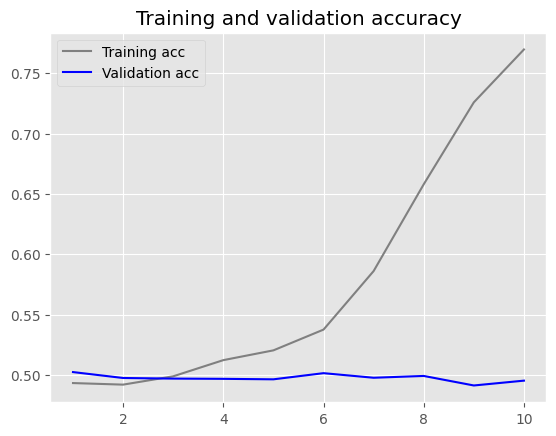

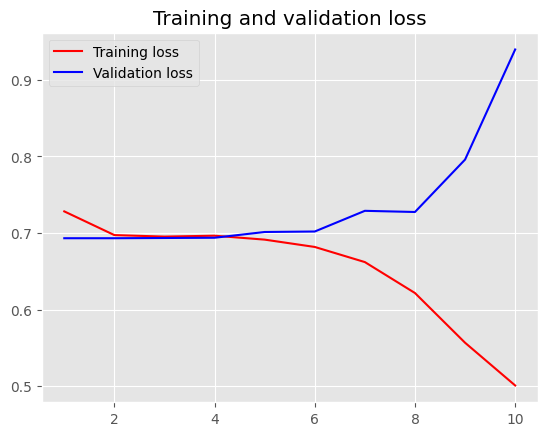

In [ ]:
import matplotlib.pyplot as plt

accuracy13 = history13.history['acc']
valid_acc13 = history13.history['val_acc']
loss13 = history13.history['loss']
valid_loss13 = history13.history['val_loss']

epochs = range(1, len(accuracy13) + 1)

plt.plot(epochs, accuracy13, 'grey', label='Training acc')
plt.plot(epochs, valid_acc13, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss13, 'red', label='Training loss')
plt.plot(epochs, valid_loss13, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [ ]:
test_loss13, test_accuracy13 = model13.evaluate(x_test, y_test)
print('Test loss:', test_loss13)
print('Test accuracy:', test_accuracy13)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.5024 - loss: 0.9252
Test loss: 0.9252335429191589
Test accuracy: 0.5023999810218811
